<a href="https://colab.research.google.com/github/thaithutram0147/Credit-Risk-Analysis/blob/main/Credit_Risk_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import necessary libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load the dataset

In [3]:
url='https://drive.google.com/file/d/1r_g77ryNXxZURcfzFEws27wmb0gfLgd0/view?usp=sharing'
url='https://drive.google.com/uc?id=' + url.split('/')[-2]
df= pd.read_csv(url,encoding='ISO-8859-1')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


Understanding the data

In [5]:
print(df.shape)
print(df.dtypes)

(32581, 12)
person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object


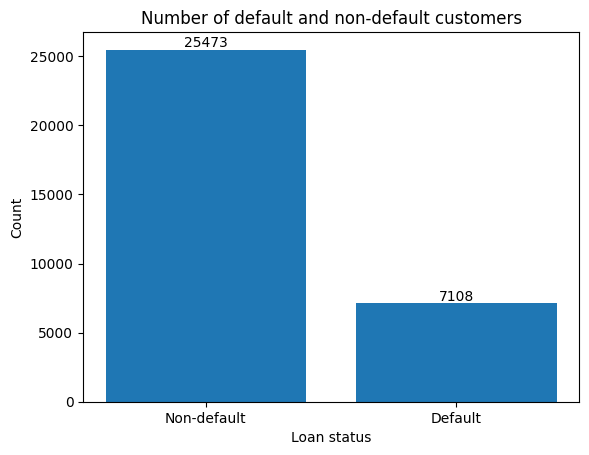

In [6]:
# Plot a bar chart showing the number of default and non-default customers
default_counts = df['loan_status'].value_counts()
plt.bar(['Non-default','Default'], [default_counts[0], default_counts[1]])

# Display values on top of the bars
for index, value in enumerate(default_counts.values):
    plt.text(index, value + 0.1, str(value), ha='center', va='bottom')

# Set labels
plt.xlabel('Loan status')
plt.ylabel('Count')
plt.title('Number of default and non-default customers')

# Display the chart
plt.show()

Exploratory Data Analysis (EDA)

In [7]:
# Check for missing values
print("Number of missing values in each column")
df.isna().sum()

Number of missing values in each column


,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


Analyze statistical metrics of numerical variables

In [8]:
# Select numerical columns (int and float) excluding loan_status
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('loan_status')

# Display full numbers
pd.set_option('display.float_format', '{:.2f}'.format)

# Basic statistics
print(df[numeric_cols].describe())

       person_age  person_income  person_emp_length  loan_amnt  loan_int_rate  \
count    32581.00       32581.00           31686.00   32581.00       29465.00   
mean        27.73       66074.85               4.79    9589.37          11.01   
std          6.35       61983.12               4.14    6322.09           3.24   
min         20.00        4000.00               0.00     500.00           5.42   
25%         23.00       38500.00               2.00    5000.00           7.90   
50%         26.00       55000.00               4.00    8000.00          10.99   
75%         30.00       79200.00               7.00   12200.00          13.47   
max        144.00     6000000.00             123.00   35000.00          23.22   

       loan_percent_income  cb_person_cred_hist_length  
count             32581.00                    32581.00  
mean                  0.17                        5.80  
std                   0.11                        4.06  
min                   0.00                

Distribution Analysis and Outlier Detection

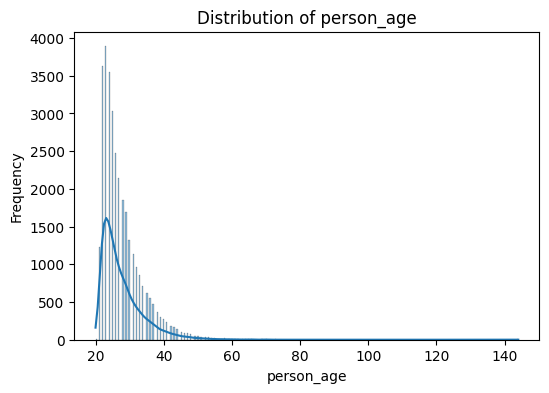

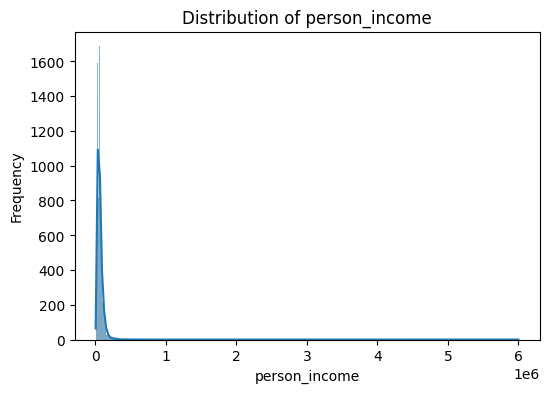

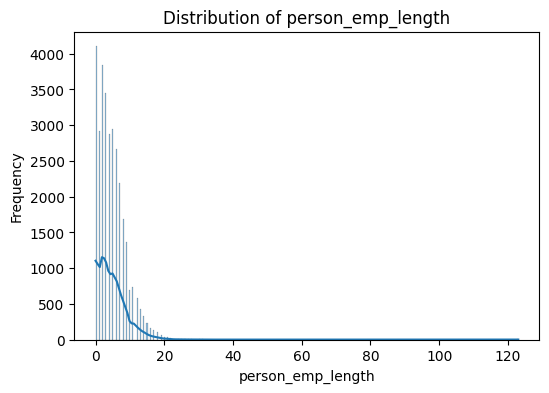

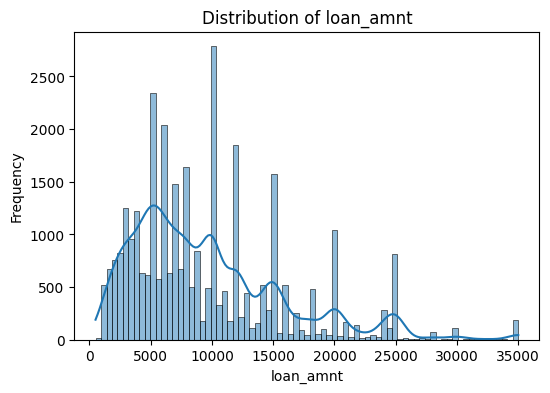

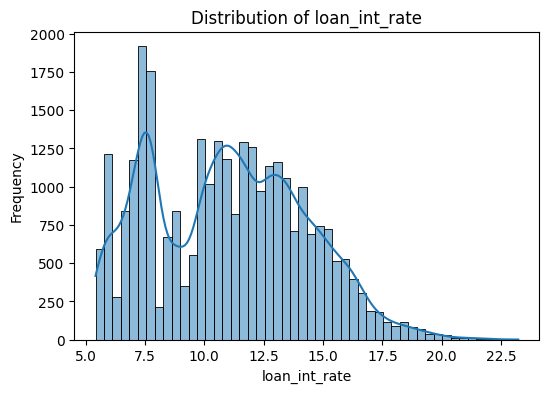

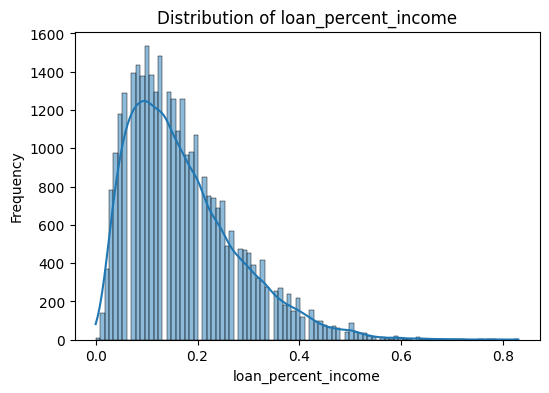

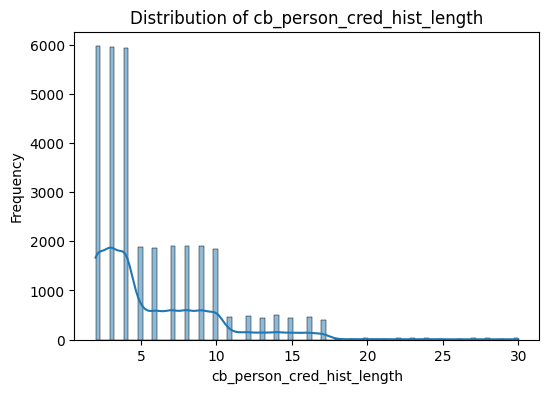

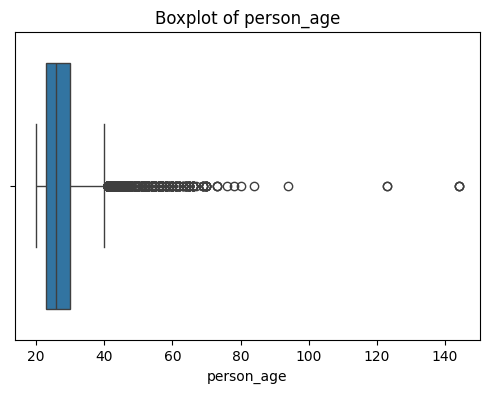

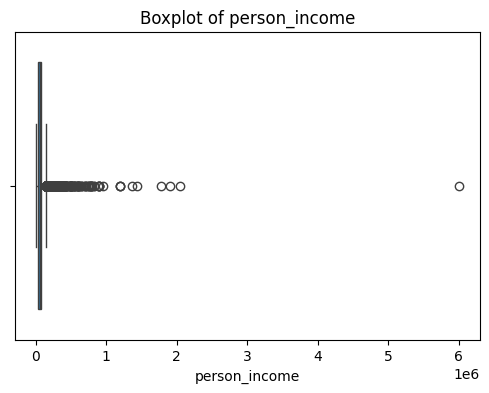

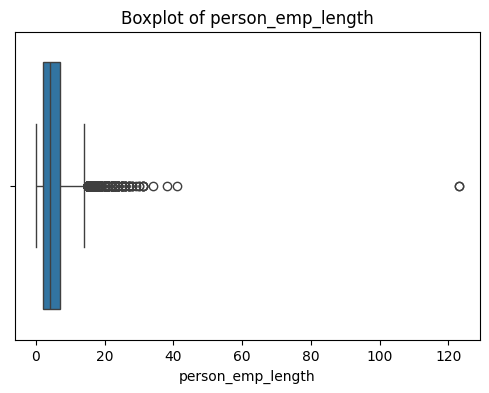

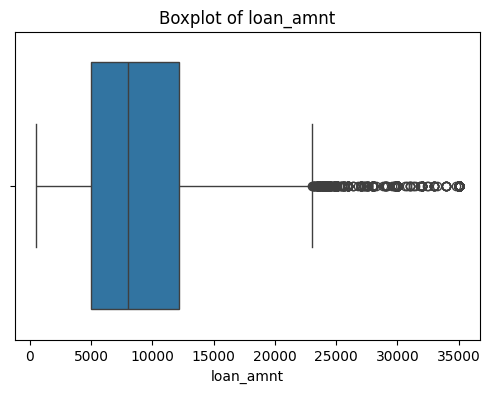

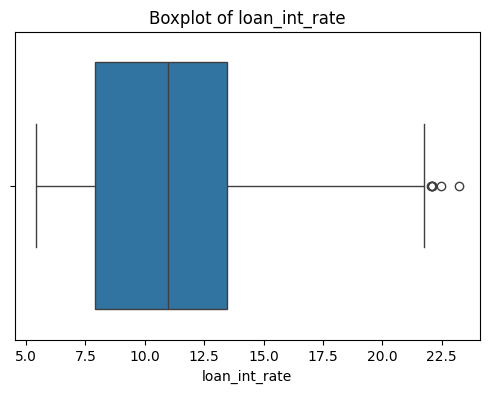

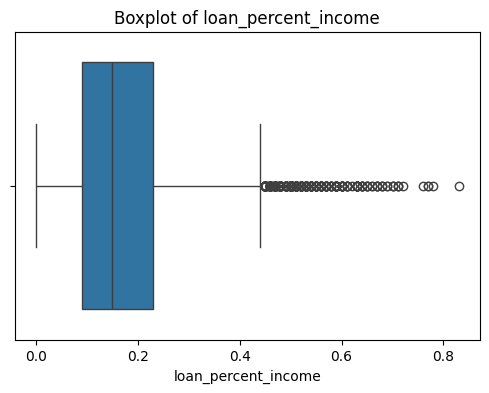

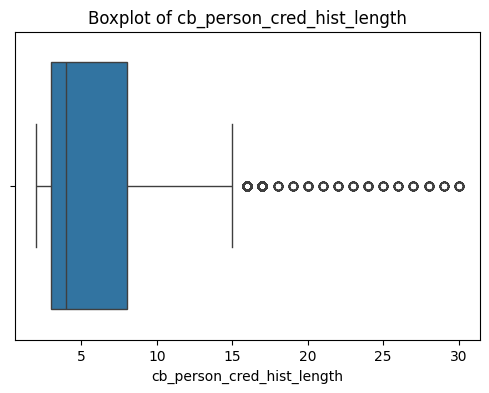

In [9]:
# Plot histogram and KDE for each numerical column
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Plot boxplots to detect outliers
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

Data Preprocessing

In [10]:
# Handle missing values

df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].mean())
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

# Check missing values after filling
print("Number of missing values in each column after filling")
df.isna().sum()


Number of missing values in each column after filling


,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_status,0
loan_percent_income,0


Encode categorical variables

In [11]:
# Label encode all remaining categorical columns
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

print(df_encoded.dtypes)
print(df_encoded.head())

person_age                      int64
person_income                   int64
person_home_ownership           int64
person_emp_length             float64
loan_intent                     int64
loan_grade                      int64
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file       int64
cb_person_cred_hist_length      int64
dtype: object
   person_age  person_income  person_home_ownership  person_emp_length  \
0          22          59000                      3             123.00   
1          21           9600                      2               5.00   
2          25           9600                      0               1.00   
3          23          65500                      3               4.00   
4          24          54400                      3               8.00   

   loan_intent  loan_grade  loan_amnt  loan_int_rate  loan_status  \
0            4  

Split features and target variable

In [12]:
x = df_encoded.drop('loan_status',axis = 1)
y = df_encoded['loan_status']

Train-Test Split

In [13]:
from sklearn.model_selection import train_test_split
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=42)

print("Number of samples in the train set:", len(X_train))
print("Number of samples in the test set:", len(X_test))

Number of samples in the train set: 26064
Number of samples in the test set: 6517


Analyze the correlation between numerical variables and the target variable

loan_percent_income           0.32
loan_int_rate                 0.29
loan_amnt                     0.09
cb_person_cred_hist_length   -0.02
person_age                   -0.03
person_emp_length            -0.09
person_income                -0.27
dtype: float64


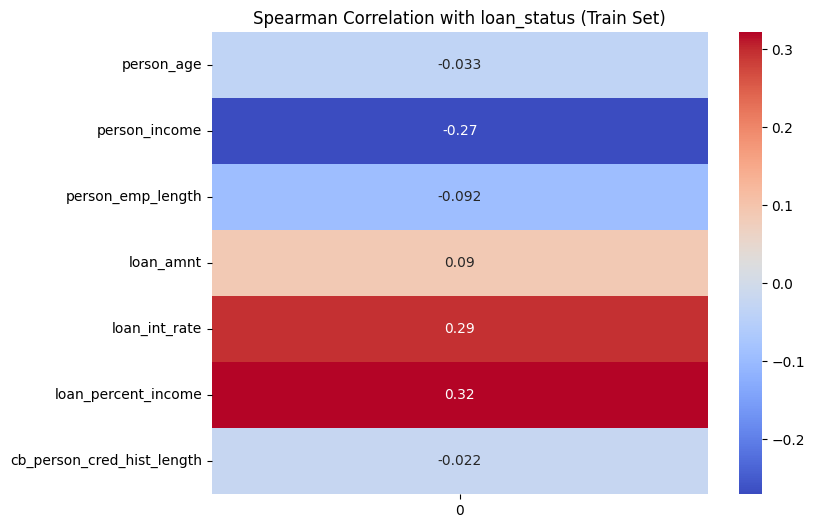

In [14]:
# Calculate Spearman correlation on the training set
corr_target = X_train[numeric_cols].corrwith(
    y_train,
    method='spearman'
)
# Sort in descending order
print(corr_target.sort_values(ascending=False))

# Plot heatmap
plt.figure(figsize=(8,6))

sns.heatmap(corr_target.to_frame(),annot=True,cmap='coolwarm')

plt.title('Spearman Correlation with loan_status (Train Set)')
plt.show()

Analyze Feature Distributions by Loan Status

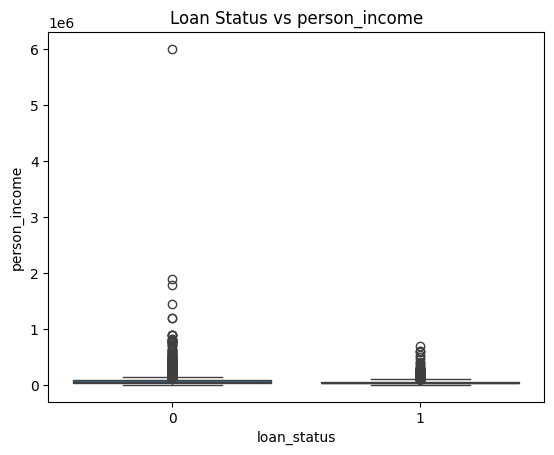

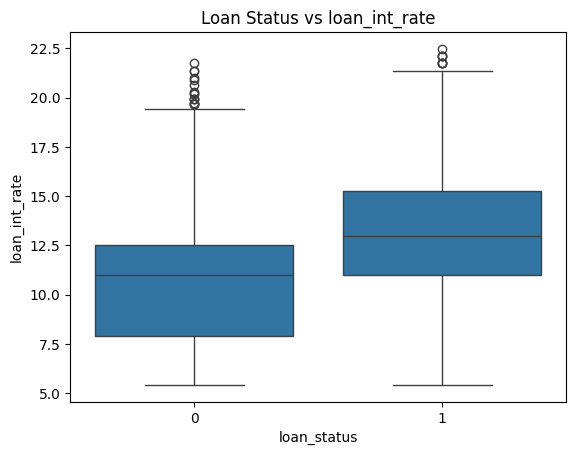

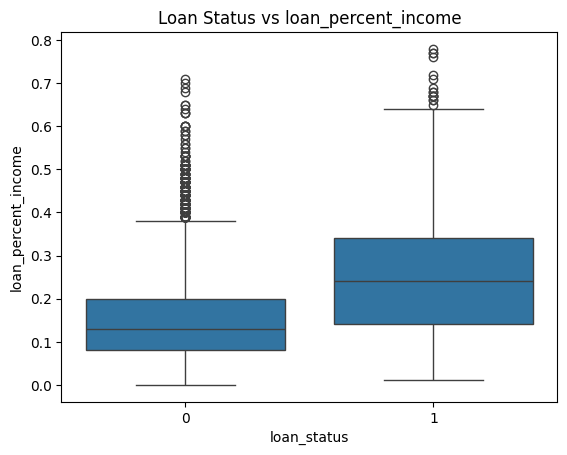

In [15]:
# Combine X_train and y_train
train_df = X_train.copy()
train_df['loan_status'] = y_train

# Feature distributions by loan status
features_to_plot = ['person_income', 'loan_int_rate', 'loan_percent_income']

for feat in features_to_plot:
    sns.boxplot(x='loan_status', y=feat, data=train_df)
    plt.title(f'Loan Status vs {feat}')
    plt.show()


Feature selection

In [16]:
selected_features = ['person_home_ownership', 'loan_intent', 'loan_grade','cb_person_default_on_file'] + features_to_plot

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

Logistic Regression

In [17]:
from sklearn.linear_model import LogisticRegression
from imblearn.combine import SMOTEENN
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline

# Create pipeline
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smoteenn', SMOTEENN(random_state=42)),
    ('lr', LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

In [18]:
from scipy.stats import loguniform, uniform
from sklearn.model_selection import RandomizedSearchCV

# Define the hyperparameter search space
param_dist = {
    'lr__C': loguniform(1e-3, 100),
    'lr__penalty': ['l2'],
    'lr__solver': ['lbfgs', 'liblinear'],
    'lr__class_weight': [None,'balanced']
}

In [ ]:
# Random Search
random_search_lr = RandomizedSearchCV(
    estimator=lr_pipeline,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

# Train the model
random_search_lr.fit(X_train_selected, y_train)

# Print the best parameters
print("Best Parameters: ",random_search_lr.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Parameters:  {'lr__C': np.float64(14.528246637516036), 'lr__class_weight': 'balanced', 'lr__penalty': 'l2', 'lr__solver': 'liblinear'}


In [19]:
# Reinitialize the model with the best parameters
best_lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('smoteenn', SMOTEENN(random_state=42)),
     ('lr', LogisticRegression(
        C=14.528246637516036,
        class_weight='balanced',
        penalty='l2',
        solver='liblinear',
        random_state=42,
        max_iter=1000
    ))
])

# Train the model
best_lr_model.fit(X_train_selected, y_train)

# Predict on the test set
y_pred_lr = best_lr_model.predict(X_test_selected)

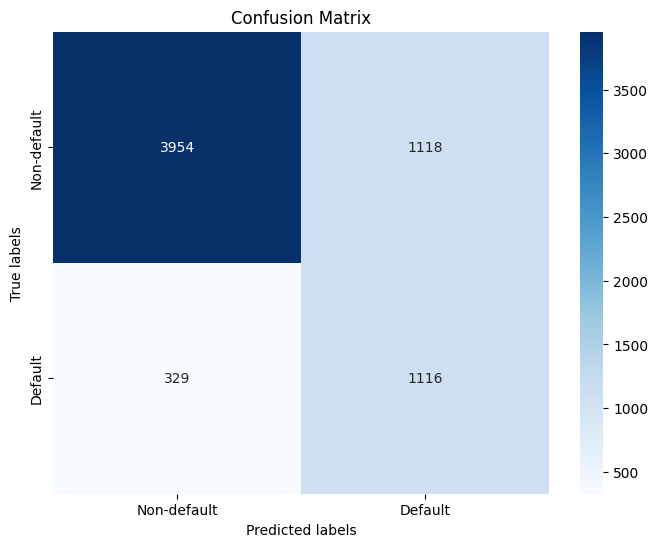

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Confusion Matrix
lr_cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(lr_cm, annot=True, cmap='Blues', fmt='d',
            xticklabels=['Non-default', 'Default'],
            yticklabels=['Non-default', 'Default'])
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

In [21]:
# Class-wise Performance Report
print("\nClassification Report:")
print(classification_report(y_test,y_pred_lr))


Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.78      0.85      5072
           1       0.50      0.77      0.61      1445

    accuracy                           0.78      6517
   macro avg       0.71      0.78      0.73      6517
weighted avg       0.83      0.78      0.79      6517



In [22]:
LR_report_dict = classification_report(y_test,y_pred_lr,output_dict=True)

# Overall Performance Report
print("===== Logistic Regression Model General Report =====")

print("Accuracy :",LR_report_dict['accuracy'])
print("Precision:",LR_report_dict['weighted avg']['precision'])
print("Recall   :",LR_report_dict['weighted avg']['recall'])
print("F1-score :",LR_report_dict['weighted avg']['f1-score'])

===== Logistic Regression Model General Report =====
Accuracy : 0.7779653214669326
Precision: 0.8292536279794669
Recall   : 0.7779653214669326
F1-score : 0.7924109560513961


SVM Model

In [23]:
from sklearn.svm import SVC
from scipy.stats import uniform

# Create pipeline
SVM_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smoteenn', SMOTEENN(random_state=42)),
    ('svm', SVC(random_state=42))
])

In [24]:
# Define the hyperparameter search space
param_dist = {
    'svm__C': [0.01, 0.1, 1, 10, 100],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
}

In [24]:
# RandomSearch
random_search = RandomizedSearchCV(
    SVM_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

# Train the model
random_search.fit(X_train_selected, y_train)

# Print the best parameters
print("Best parameters found:", random_search.best_params_)

best_svm_model = random_search.best_estimator_

Best parameters found: {'svm__kernel': 'rbf', 'svm__gamma': 0.1, 'svm__C': 100}


In [25]:
# Reinitialize the model with the best parameters
best_svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('smoteenn', SMOTEENN(random_state=42)),
    ('svm', SVC(
        kernel='rbf',
        gamma=0.1,
        C=100,
        random_state=42
    ))
])

# Train the model
best_svm_model.fit(X_train_selected, y_train)

# Predict on the test set
y_pred_svm = best_svm_model.predict(X_test_selected)

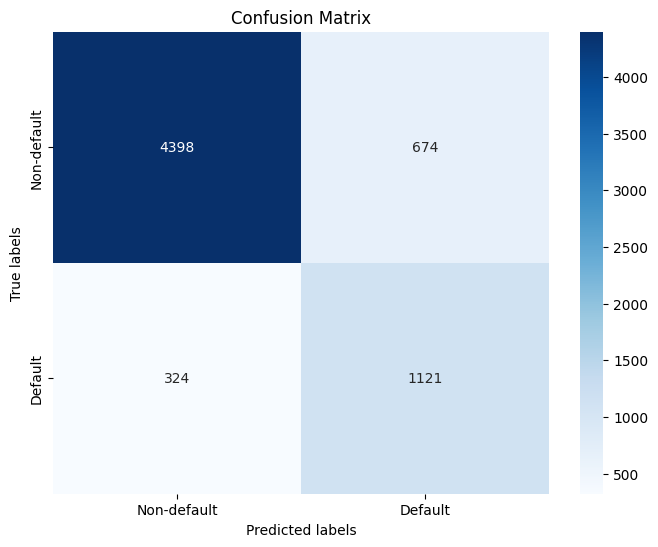

In [26]:
# Confusion Matrix
svm_cm = confusion_matrix(y_test,y_pred_svm)

plt.figure(figsize=(8, 6))
sns.heatmap(svm_cm, annot=True, cmap='Blues', fmt='d',
            xticklabels=['Non-default', 'Default'],
            yticklabels=['Non-default', 'Default'])
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

In [27]:
# Class-wise Performance Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.87      0.90      5072
           1       0.62      0.78      0.69      1445

    accuracy                           0.85      6517
   macro avg       0.78      0.82      0.80      6517
weighted avg       0.86      0.85      0.85      6517



In [28]:
SVM_report_dict = classification_report(y_test,y_pred_svm,output_dict=True)

# Overall Performance Report
print("===== SVM Model General Report =====")

print("Accuracy :",SVM_report_dict['accuracy'])
print("Precision:",SVM_report_dict['weighted avg']['precision'])
print("Recall   :",SVM_report_dict['weighted avg']['recall'])
print("F1-score :",SVM_report_dict['weighted avg']['f1-score'])

===== SVM Model General Report =====
Accuracy : 0.8468620530919134
Precision: 0.863342851777966
Recall   : 0.8468620530919134
F1-score : 0.8523971113477312


XG Boost

Feature Selection using POA (Pelican Optimization Algorithm)

In [29]:
import numpy as np
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier

# Optimized fitness function
def fitness_function(selected_features_idx, x, y):
    # If no features or too few features are selected, return the worst score
    if len(selected_features_idx) < 2:
        return 0

    # Get the feature subset (x should be a NumPy array for faster access)
    X_subset = x[:, selected_features_idx]

    # Configure a simple XGBoost model
    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        eval_metric='logloss',
        tree_method='hist',
        n_jobs=-1,
        random_state=42
    )

    # Use CV=5 for more stable evaluation
    scores = cross_val_score(
        model, X_subset, y, cv=5, scoring='f1', n_jobs=-1
    )

    f1_mean = scores.mean()

    # Apply a penalty based on the ratio of selected features
    penalty = 0.01 * (len(selected_features_idx) / x.shape[1])

    return f1_mean - penalty

# Define v_func outside the fitness_function
def v_func(x):
    # The absolute value of tanh(x) helps flip bits (0->1 or 1->0)
    return abs(np.tanh(x))

In [30]:
# Convert X_train to NumPy array
X_np = X_train.values if isinstance(X_train, pd.DataFrame) else X_train
y_np = y_train.values if isinstance(y_train, pd.Series) else y_train

n_features = X_np.shape[1]
pop_size = 15
iterations = 30

In [31]:
# Initialize the population (low feature selection probability to make pelicans fly lighter)
population = np.random.choice([0, 1], size=(pop_size, n_features), p=[0.7, 0.3])

best_solution = None
best_score = -1

In [1]:
# # --- POA MAIN LOOP ---
# print("--- Start POA Hunting Process ---")

# for it in range(iterations):
#     # Bước 1: Evaluate Fitness
#     for i in range(pop_size):
#         selected_idx = np.where(population[i] == 1)[0]
#         score = fitness_function(selected_idx, X_np, y_np)

#         if score > best_score:
#             best_score = score
#             best_solution = population[i].copy()

#     # Phase 2: Update population positions based on the standard POA
#     new_population = np.zeros_like(population)

#     for i in range(pop_size):
#         # Phase 1: Move toward prey (Exploration)
#         r1 = np.random.rand(n_features)
#         I = np.random.randint(1, 3)

#         # Calculate movement direction (step) based on the best prey
#         step = r1 * (best_solution - I * population[i])

#         for j in range(n_features):
#             # V-SHAPE MECHANISM: Bit-flipping probability
#             if np.random.rand() < v_func(step[j]):
#                 # If the probability falls into the flipping region, reverse the state (1 -> 0, 0 -> 1)
#                 new_population[i][j] = 1 - population[i][j]
#             else:
#                 # Otherwise, keep the current feature
#                 new_population[i][j] = population[i][j]

#         # Phase 2: Hunting on the water surface (Exploitation - Local Search)
#         # Create a small mutation around the current position for more detailed searching
#         if np.random.rand() < 0.2:
#             flip_idx = np.random.randint(0, n_features)
#             new_population[i][flip_idx] = 1 - new_population[i][flip_idx]

#     population = new_population.copy()
#     print(f"Iteration {it+1}/{iterations}, Best Score: {best_score:.4f}, Features: {int(sum(best_solution))}")

# # --- RESULTS ---
# POA_selected_features = np.where(best_solution == 1)[0]
# print("-" * 30)
# print(f"Completed! Selected {len(POA_selected_features)} features.")
# print(f"Selected feature indices: {POA_selected_features}")

Feature selection

In [32]:
POA_selected_feature_names = ['person_age','person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade',
       'loan_percent_income']

In [33]:
X_train_POA = X_train[POA_selected_feature_names]
X_test_POA = X_test[POA_selected_feature_names]

In [34]:
pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 8.1 MB/s eta 0:00:00


In [35]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer,Categorical

# Initialize the model
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

In [36]:
# Define the hyperparameter search space
param_space = {
    "n_estimators": Integer(100, 500),
    "learning_rate": Real(0.01, 0.3, prior='log-uniform'),
    "max_depth": Integer(3, 10),
    "subsample": Real(0.6, 1.0),
    "colsample_bytree": Real(0.6, 1.0),
    "gamma": Real(0, 1.0),
    "min_child_weight": Integer(1, 10),
    "scale_pos_weight": Real(1, 5)
}

In [38]:
# # Bayesian optimization setup
# bayes_search = BayesSearchCV(
#     estimator=xgb,
#     search_spaces=param_space,
#     n_iter=30,
#     scoring='f1',
#     cv=3,
#     n_jobs=-1,
#     random_state=42,
#     verbose=2
# )

# # Train the model
# bayes_search.fit(X_train_POA, y_train)

# # Print the best parameters
# print("Best Parameters:", bayes_search.best_params_)

In [39]:
# Reinitialize the model with the best parameters
best_xgb_model = XGBClassifier(
    subsample=0.7172601275660485,
    scale_pos_weight=1.0,
    n_estimators=174,
    min_child_weight=4,
    max_depth=5,
    learning_rate=0.12841655574993596,
    gamma=0.0,
    colsample_bytree=0.9130870393560118,
    random_state=42,
    eval_metric='logloss'
)

# Train the model
best_xgb_model.fit(X_train_POA, y_train)

# Predict on the test set
y_pred_xgb = best_xgb_model.predict(X_test_POA)

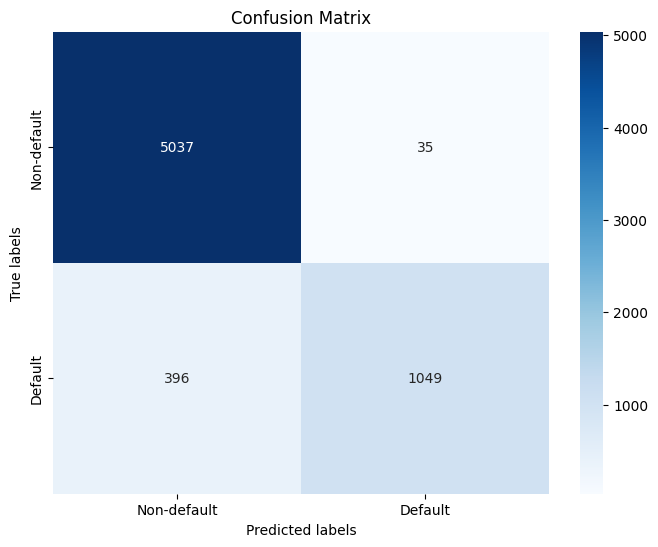

In [40]:
# Confusion Matrix
xgb_cm = confusion_matrix(y_test,y_pred_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(xgb_cm, annot=True, cmap='Blues', fmt='d',
            xticklabels=['Non-default', 'Default'],
            yticklabels=['Non-default', 'Default'])
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

In [41]:
# Class-wise Performance Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5072
           1       0.97      0.73      0.83      1445

    accuracy                           0.93      6517
   macro avg       0.95      0.86      0.89      6517
weighted avg       0.94      0.93      0.93      6517



In [42]:
XGBoost_report_dict = classification_report(y_test,y_pred_xgb,output_dict=True)

# Overall Performance Report
print("===== XG Boost Model General Report =====")

print("Accuracy :",XGBoost_report_dict['accuracy'])
print("Precision:",XGBoost_report_dict['weighted avg']['precision'])
print("Recall   :",XGBoost_report_dict['weighted avg']['recall'])
print("F1-score :",XGBoost_report_dict['weighted avg']['f1-score'])

===== XG Boost Model General Report =====
Accuracy : 0.9338652754334816
Precision: 0.9361142596980633
Recall   : 0.9338652754334816
F1-score : 0.9302814486185481


MLP

In [44]:
from sklearn.neural_network import MLPClassifier

# Create pipeline
MLP_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smoteenn', SMOTEENN(random_state=42)),
    ('mlp', MLPClassifier(
        random_state=42,
        max_iter=1000
    ))
])

In [45]:
# Define the hyperparameter search space
param_space = {
    'mlp__hidden_layer_sizes': Integer(32,128),
    'mlp__activation': Categorical(['relu', 'tanh']),
    'mlp__solver': Categorical(['adam', 'lbfgs']),
    'mlp__alpha': Real(1e-5, 1e-1, prior='log-uniform'),
    'mlp__learning_rate_init': Real(1e-4, 1e-1, prior='log-uniform'),
    'mlp__batch_size': Categorical([16, 32, 64, 128]),
}

In [47]:
# # BAYESIAN OPTIMIZATION

# MLP_bayes_search = BayesSearchCV(

#     estimator=MLP_pipeline,
#     search_spaces=param_space,
#     n_iter=30,
#     scoring='f1',
#     cv=3,
#     n_jobs=-1,
#     return_train_score=True,
#     random_state=42,
#     verbose=2
# )

# # Train the model
# MLP_bayes_search.fit(X_train_selected, y_train)

# # Print the best parameters
# print("Best_params: ",MLP_bayes_search.best_params_)

In [48]:
# Reinitialize the model with the best parameters
best_mlp_model = Pipeline([
    ('scaler', StandardScaler()),
    ('smoteenn', SMOTEENN(random_state=42)),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=32,
        activation='tanh',
        solver='adam',
        alpha=1e-05,
        learning_rate_init=0.0027943504902700755,
        batch_size=32,
        random_state=42,
        max_iter=1000
    ))
])

# Train the model
best_mlp_model.fit(X_train_selected, y_train)

# Predict on the test set
y_pred_mlp = best_mlp_model.predict(X_test_selected)

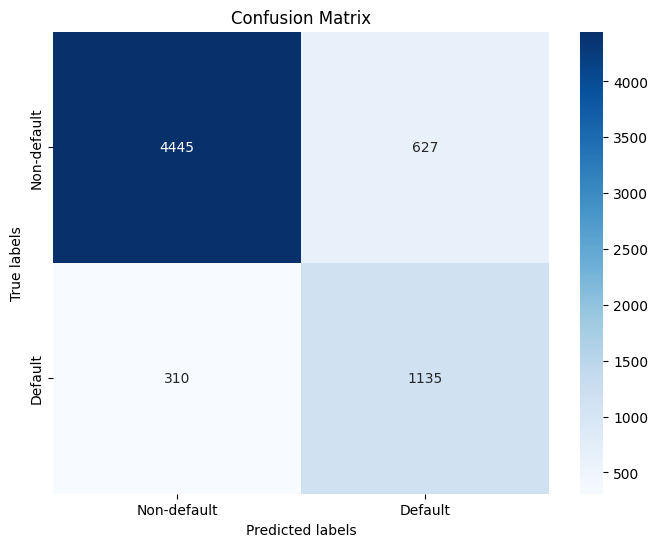

In [49]:
# Confusion Matrix
mlp_cm = confusion_matrix(y_test,y_pred_mlp)

plt.figure(figsize=(8, 6))
sns.heatmap(mlp_cm, annot=True, cmap='Blues', fmt='d',
            xticklabels=['Non-default', 'Default'],
            yticklabels=['Non-default', 'Default'])
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

In [50]:
# Class-wise Performance Report
print("\nClassification Report:")
print(classification_report(y_test,y_pred_mlp))


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.88      0.90      5072
           1       0.64      0.79      0.71      1445

    accuracy                           0.86      6517
   macro avg       0.79      0.83      0.81      6517
weighted avg       0.87      0.86      0.86      6517



In [51]:
MLP_report_dict = classification_report(y_test,y_pred_mlp,output_dict=True)

# Overall Performance Report
print("===== MLP Model General Report =====")

print("Accuracy :",MLP_report_dict['accuracy'])
print("Precision:",MLP_report_dict['weighted avg']['precision'])
print("Recall   :",MLP_report_dict['weighted avg']['recall'])
print("F1-score :",MLP_report_dict['weighted avg']['f1-score'])

===== MLP Model General Report =====
Accuracy : 0.8562221881233697
Precision: 0.8703600426626574
Recall   : 0.8562221881233697
F1-score : 0.8610091416354615


Compare Model Performance

In [52]:
# Combine the results of all models
results = [
    {
        'Model': 'Logistic Regression',
        'Accuracy': LR_report_dict['accuracy'],
        'Precision': LR_report_dict['weighted avg']['precision'],
        'Recall': LR_report_dict['weighted avg']['recall'],
        'F1-score': LR_report_dict['weighted avg']['f1-score']
    },

    {
        'Model': 'SVM',
        'Accuracy': SVM_report_dict['accuracy'],
        'Precision': SVM_report_dict['weighted avg']['precision'],
        'Recall': SVM_report_dict['weighted avg']['recall'],
        'F1-score': SVM_report_dict['weighted avg']['f1-score']
    },

    {
        'Model': 'XGBoost',
        'Accuracy': XGBoost_report_dict['accuracy'],
        'Precision': XGBoost_report_dict['weighted avg']['precision'],
        'Recall': XGBoost_report_dict['weighted avg']['recall'],
        'F1-score': XGBoost_report_dict['weighted avg']['f1-score']
    },

    {
        'Model': 'MLP',
        'Accuracy': MLP_report_dict['accuracy'],
        'Precision': MLP_report_dict['weighted avg']['precision'],
        'Recall': MLP_report_dict['weighted avg']['recall'],
        'F1-score': MLP_report_dict['weighted avg']['f1-score']
    }
]

# Convert the results into a DataFrame and display the comparison results
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.78,0.83,0.78,0.79
1,SVM,0.85,0.86,0.85,0.85
2,XGBoost,0.93,0.94,0.93,0.93
3,MLP,0.86,0.87,0.86,0.86
